# Hail M0 - MYRORSS Source Qualification - Selected-Cell Adapter Scan v0

**Peril:** hail - **Layer:** M0 input evidence - **Mode:** common source qualification with a
CONUS-grid selected-cell adapter proof

This notebook is the next step after `01_myrorss_meet_data`: use the MYRORSS sparse-grid reader to scan the
four locked selected cells on a small, explicit set of MYRORSS-era days.

## Step back - what this is and is not

The full MYRORSS record is 1998-2011. A naive full scan means roughly:

```text
14 years x ~365 days/year x ~300 MESH files/day = O(1.5 million netCDF files)
```

That is not a first notebook run. The right first selected-cell run is:

1. reuse cached NOAA Storm Events only to choose a few stress-test dates;
2. scan MYRORSS itself on those dates for all four selected cells;
3. write a daily selected-cell panel with explicit zero days and coverage status;
4. compare the result against the MRMS-only pilot without blending the sources.

Source roles stay strict:

- **NOAA Storm Events:** date-selection aid for this v0 stress test only. It is not grid truth.
- **MYRORSS:** gridded evidence source being scanned.
- **MRMS pilot:** current downstream interface reference, not a calibration target here.

This notebook does **not** produce final frequency, PML, VaR, TVaR, or EAL inputs.

Plan links:

- `docs/plans/hazard_conus_grid/hail/m0_m1_hazard_layer.md`
- `docs/plans/hazard_conus_grid/hail/pilot_cell_selection.md`
- `docs/principles/notebook_work/exploratory_data_notebooks.md`

## 0 - Scope and outputs

This notebook does:

- load the locked selected cells;
- load cached NOAA 25-mile report data for those cells;
- pick the top two MYRORSS-era report dates per selected-cell role;
- add the already-inspected MYRORSS source-probe day;
- scan MYRORSS MESH for all four selected cells on those dates;
- materialize explicit zero rows when a selected cell has no sparse MYRORSS pixel that day;
- write small daily-panel, summary, scan-date, and metadata artifacts.

It deliberately does not:

- scan all 1998-2011 days;
- claim report-guided dates are an unbiased frequency sample;
- use NOAA report counts as events;
- merge MYRORSS into M1;
- estimate annual `lambda_cell`.

In [1]:
from __future__ import annotations

import gzip
import json
import tempfile
import xml.etree.ElementTree as ET
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
from urllib.parse import quote

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xarray as xr
from IPython.display import display

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 115})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
HAIL_GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "hail"
RAW_MYRORSS_DIR = HAIL_GRID_DIR / "raw_myrorss"
RAW_REPORT_DIR = HAIL_GRID_DIR / "report_qa_raw"
RAW_MYRORSS_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_CELLS_CSV = HAIL_GRID_DIR / "selected_pilot_cells_v2026_06_16.csv"
MRMS_M1_DAILY_PANEL_CSV = HAIL_GRID_DIR / "m1_selected_cell_daily_panel_v2026_06_16.csv"

OUTPUT_VERSION = "v2026_06_16"
DATES_PER_ROLE = 2
SEVERE_HAIL_MM = 25.4
SOURCE_PROBE_DATE = pd.Timestamp("2010-06-16").date()

SCAN_DATES_CSV = HAIL_GRID_DIR / f"myrorss_m0_selected_cell_scan_dates_{OUTPUT_VERSION}.csv"
DAILY_PANEL_CSV = HAIL_GRID_DIR / f"myrorss_m0_selected_cell_report_guided_daily_panel_{OUTPUT_VERSION}.csv"
SUMMARY_CSV = HAIL_GRID_DIR / f"myrorss_m0_selected_cell_report_guided_summary_{OUTPUT_VERSION}.csv"
METADATA_JSON = HAIL_GRID_DIR / f"myrorss_m0_selected_cell_report_guided_metadata_{OUTPUT_VERSION}.json"

print("repo root:", ROOT)
print("selected cells:", SELECTED_CELLS_CSV.relative_to(ROOT))
print("MYRORSS raw cache:", RAW_MYRORSS_DIR.relative_to(ROOT))
print("cached report raw:", RAW_REPORT_DIR.relative_to(ROOT))
print("dates per selected-cell role:", DATES_PER_ROLE)

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
selected cells: data/hazard_conus_grid/hail/selected_pilot_cells_v2026_06_16.csv
MYRORSS raw cache: data/hazard_conus_grid/hail/raw_myrorss
cached report raw: data/hazard_conus_grid/hail/report_qa_raw
dates per selected-cell role: 2


## 1 - Load selected cells and define the field contract

The selected-cell manifest is the durable four-cell input. The MRMS candidate and report-QA files remain
provenance only.

In [2]:
selected_cells = pd.read_csv(SELECTED_CELLS_CSV)
selected_cells = selected_cells[
    [
        "hazard",
        "selection_version",
        "role",
        "cell_id",
        "lat_center",
        "lon_center",
        "state_abbr",
        "iso_rto",
        "allowed_use",
        "not_allowed_use",
    ]
].copy()

selected_ids = set(selected_cells["cell_id"].astype(int))
display(selected_cells)


def neighbor_cell_ids_3x3(cell_id: int) -> list[int]:
    lat_idx = int(cell_id) // 1440
    lon_idx = int(cell_id) % 1440
    ids: list[int] = []
    for d_lat in (-1, 0, 1):
        for d_lon in (-1, 0, 1):
            n_lat = lat_idx + d_lat
            n_lon = (lon_idx + d_lon) % 1440
            if 0 <= n_lat < 720:
                ids.append(n_lat * 1440 + n_lon)
    return sorted(set(ids))


neighbor_map = {
    int(row.cell_id): neighbor_cell_ids_3x3(int(row.cell_id))
    for row in selected_cells.itertuples(index=False)
}
scan_target_ids = set().union(*neighbor_map.values())
neighbor_manifest = pd.DataFrame(
    [
        {
            "role": row.role,
            "cell_id": int(row.cell_id),
            "neighbor_3x3_cell_ids": ",".join(str(x) for x in neighbor_map[int(row.cell_id)]),
            "n_neighbor_3x3_cells": len(neighbor_map[int(row.cell_id)]),
        }
        for row in selected_cells.itertuples(index=False)
    ]
)
display(neighbor_manifest)

field_contract = pd.DataFrame(
    [
        ("cell_id", "benchmark grid key", "integer", "YES - selected-cell identity"),
        ("date", "MYRORSS calendar day scanned", "date", "YES - daily panel key"),
        ("n_source_files", "MYRORSS MESH files listed under that day", "file count", "YES - coverage/provenance"),
        ("n_empty_source_files", "listed MYRORSS files with zero bytes", "file count", "YES - source QA; skip as no readable grid"),
        ("positive_native_pixel_records", "sparse MYRORSS pixels falling in the selected cell", "record count", "YES - support indicator, not area denominator"),
        ("severe_native_pixel_records", "selected-cell sparse pixels with MESH >= 25.4 mm", "record count", "YES - severe support indicator"),
        ("neighbor_3x3_*", "same-day MYRORSS context in the selected cell plus adjacent 8 cells", "cell/pixel counts and mm", "QA ONLY - distinguishes exact-cell miss from nearby hail"),
        ("hail_day_flag", "whether selected cell has any severe MYRORSS pixel that day", "boolean", "YES - daily severe flag for this source"),
        ("mesh_max_mm", "maximum selected-cell MYRORSS MESH on that day", "mm", "YES - conditional size evidence"),
        ("coverage_status", "listed/no sparse/sparse/error status", "category", "YES - prevents silent zeros"),
        ("date_selection_reason", "why this day was scanned", "category", "YES - this v0 is not an unbiased sample"),
        ("report_guided_*", "NOAA report context used for date selection", "report count/inches", "CONTEXT ONLY - not grid truth"),
    ],
    columns=["field", "what it is", "units / base", "how we use it"],
)
display(field_contract)

,hazard,selection_version,role,cell_id,lat_center,lon_center,state_abbr,iso_rto,allowed_use,not_allowed_use
0,hail,v2026_06_16,high_hail,329354,33.00,-101.50,TX,ERCOT,selected-cell M1 pilot only,not production CONUS hail climatology; not fin...
1,hail,v2026_06_16,medium_hail,261700,44.75,-95.00,MN,MISO,selected-cell M1 pilot only,not production CONUS hail climatology; not fin...
2,hail,v2026_06_16,low_hail,247197,47.25,-120.75,WA,WEIM,selected-cell M1 pilot only,not production CONUS hail climatology; not fin...
3,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,selected-cell M1 pilot only,not production CONUS hail climatology; not fin...


,role,cell_id,neighbor_3x3_cell_ids,n_neighbor_3x3_cells
0,high_hail,329354,"327913,327914,327915,329353,329354,329355,3307...",9
1,medium_hail,261700,"260259,260260,260261,261699,261700,261701,2631...",9
2,low_hail,247197,"245756,245757,245758,247196,247197,247198,2486...",9
3,hayhurst_reference,336544,"335103,335104,335105,336543,336544,336545,3379...",9


,field,what it is,units / base,how we use it
0,cell_id,benchmark grid key,integer,YES - selected-cell identity
1,date,MYRORSS calendar day scanned,date,YES - daily panel key
2,n_source_files,MYRORSS MESH files listed under that day,file count,YES - coverage/provenance
3,n_empty_source_files,listed MYRORSS files with zero bytes,file count,YES - source QA; skip as no readable grid
4,positive_native_pixel_records,sparse MYRORSS pixels falling in the selected ...,record count,"YES - support indicator, not area denominator"
5,severe_native_pixel_records,selected-cell sparse pixels with MESH >= 25.4 mm,record count,YES - severe support indicator
6,neighbor_3x3_*,same-day MYRORSS context in the selected cell ...,cell/pixel counts and mm,QA ONLY - distinguishes exact-cell miss from n...
7,hail_day_flag,whether selected cell has any severe MYRORSS p...,boolean,YES - daily severe flag for this source
8,mesh_max_mm,maximum selected-cell MYRORSS MESH on that day,mm,YES - conditional size evidence
9,coverage_status,listed/no sparse/sparse/error status,category,YES - prevents silent zeros


**Takeaway.** MYRORSS rows will look like an M0 daily evidence panel, but the date set is intentionally
report-guided and bounded. Do not convert this panel into annual frequency.

## 2 - Load cached NOAA reports only to pick stress dates

The report-side QA notebook already cached Hydronos/NOAA responses under `data/`. We use the 25-mile cache
here only to select likely hail days in the MYRORSS era. That is a sampling tactic, not a source blend.

In [3]:
def load_cached_noaa_reports_for_selected_cells() -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for _, cell in selected_cells.iterrows():
        pattern = f"noaa_{cell.role}_{cell.cell_id}_25mi_*.json.gz"
        matches = sorted(RAW_REPORT_DIR.glob(pattern))
        if not matches:
            continue
        with gzip.open(matches[0], "rt", encoding="utf-8") as f:
            cached = json.load(f)
        records = cached.get("payload", {}).get("data") or []
        if not records:
            continue
        frame = pd.DataFrame(records)
        frame["role"] = cell.role
        frame["cell_id"] = int(cell.cell_id)
        frame["report_cache_file"] = str(matches[0].relative_to(ROOT))
        frames.append(frame)
    if not frames:
        return pd.DataFrame()

    reports = pd.concat(frames, ignore_index=True)
    reports["BEGIN_DATE_TIME"] = pd.to_datetime(reports["BEGIN_DATE_TIME"], utc=True, errors="coerce")
    reports["report_date"] = reports["BEGIN_DATE_TIME"].dt.date
    reports["report_year"] = reports["BEGIN_DATE_TIME"].dt.year
    reports["MAGNITUDE"] = pd.to_numeric(reports["MAGNITUDE"], errors="coerce")
    reports["BEGIN_LAT"] = pd.to_numeric(reports["BEGIN_LAT"], errors="coerce")
    reports["BEGIN_LON"] = pd.to_numeric(reports["BEGIN_LON"], errors="coerce")
    return reports


reports = load_cached_noaa_reports_for_selected_cells()
myrorss_era_reports = reports.query("1998 <= report_year <= 2011").copy()

report_availability = (
    myrorss_era_reports.groupby(["role", "cell_id"], as_index=False)
    .agg(
        n_reports=("EVENT_ID", "count"),
        n_report_dates=("report_date", "nunique"),
        max_report_hail_in=("MAGNITUDE", "max"),
        first_report_date=("report_date", "min"),
        last_report_date=("report_date", "max"),
    )
    .sort_values("role")
)
display(report_availability)

report_dates = (
    myrorss_era_reports.groupby(["role", "cell_id", "report_date"], as_index=False)
    .agg(
        max_report_hail_in=("MAGNITUDE", "max"),
        n_reports=("EVENT_ID", "count"),
        report_sources=("SOURCE", lambda s: "; ".join(sorted({str(x) for x in s.dropna()}))[:300]),
    )
    .sort_values(["role", "max_report_hail_in", "n_reports"], ascending=[True, False, False])
)

display(report_dates.groupby("role").head(8))

,role,cell_id,n_reports,n_report_dates,max_report_hail_in,first_report_date,last_report_date
0,hayhurst_reference,336544,38,23,2.50,1998-10-27,2010-05-17
1,high_hail,329354,175,72,2.75,1998-05-25,2011-11-07
2,low_hail,247197,6,4,1.50,2004-05-19,2008-07-01
3,medium_hail,261700,142,70,4.25,1998-04-12,2011-07-10


,role,cell_id,report_date,max_report_hail_in,n_reports,report_sources
16,hayhurst_reference,336544,2005-06-06,2.50,3,GENERAL PUBLIC; LAW ENFORCEMENT
3,hayhurst_reference,336544,1999-05-26,2.50,2,STORM CHASER
2,hayhurst_reference,336544,1999-04-30,1.75,3,GENERAL PUBLIC; NWS EMPLOYEE(OFF DUTY)
4,hayhurst_reference,336544,2002-04-06,1.75,3,STORM CHASER; TRAINED SPOTTER
22,hayhurst_reference,336544,2010-05-17,1.75,3,Public; Storm Chaser
7,hayhurst_reference,336544,2003-06-14,1.75,2,GENERAL PUBLIC
8,hayhurst_reference,336544,2003-06-20,1.75,2,TRAINED SPOTTER
15,hayhurst_reference,336544,2005-06-02,1.75,2,GENERAL PUBLIC; LAW ENFORCEMENT
23,high_hail,329354,1998-05-25,2.75,8,TRAINED SPOTTER
25,high_hail,329354,1999-05-09,2.75,5,LAW ENFORCEMENT; TRAINED SPOTTER


**Takeaway.** These reports are not used as events. They only choose a compact set of dates where MYRORSS
has a reasonable chance of showing selected-cell hail evidence.

## 3 - Choose scan dates

We choose the top two report dates per role by reported hail size, then report count. We also add the
`2010-06-16` MYRORSS source-probe day so this notebook remains connected to the previous source probe.

In [4]:
top_report_dates = report_dates.groupby("role", group_keys=False).head(DATES_PER_ROLE).copy()
top_report_dates["date_selection_reason"] = "top_noaa_25mi_report_date_in_myrorss_era"
top_report_dates = top_report_dates.rename(columns={"report_date": "date"})

source_probe_row = pd.DataFrame(
    [
        {
            "role": "source_probe_context",
            "cell_id": pd.NA,
            "date": SOURCE_PROBE_DATE,
            "max_report_hail_in": np.nan,
            "n_reports": 0,
            "report_sources": "",
            "date_selection_reason": "source_probe_sample_day",
        }
    ]
)

scan_dates = pd.concat([top_report_dates, source_probe_row], ignore_index=True)
scan_dates["date"] = pd.to_datetime(scan_dates["date"]).dt.date
scan_dates = (
    scan_dates.sort_values(["date_selection_reason", "role", "date"])
    .drop_duplicates(subset=["date", "role", "cell_id"], keep="first")
    .reset_index(drop=True)
)

scan_date_context = (
    scan_dates.groupby("date", as_index=False)
    .agg(
        date_selection_roles=("role", lambda s: ";".join(sorted({str(x) for x in s}))),
        date_selection_reason=("date_selection_reason", lambda s: ";".join(sorted({str(x) for x in s}))),
        max_report_hail_in_any_selected_role=("max_report_hail_in", "max"),
        n_reports_any_selected_role=("n_reports", "sum"),
    )
    .sort_values("date")
)

display(scan_dates)
display(scan_date_context)

,role,cell_id,date,max_report_hail_in,n_reports,report_sources,date_selection_reason
0,source_probe_context,<NA>,2010-06-16,NaN,0,,source_probe_sample_day
1,hayhurst_reference,336544,1999-05-26,2.50,2,STORM CHASER,top_noaa_25mi_report_date_in_myrorss_era
2,hayhurst_reference,336544,2005-06-06,2.50,3,GENERAL PUBLIC; LAW ENFORCEMENT,top_noaa_25mi_report_date_in_myrorss_era
3,high_hail,329354,1998-05-25,2.75,8,TRAINED SPOTTER,top_noaa_25mi_report_date_in_myrorss_era
4,high_hail,329354,1999-05-09,2.75,5,LAW ENFORCEMENT; TRAINED SPOTTER,top_noaa_25mi_report_date_in_myrorss_era
5,low_hail,247197,2006-07-05,1.50,3,GENERAL PUBLIC; TRAINED SPOTTER,top_noaa_25mi_report_date_in_myrorss_era
6,low_hail,247197,2008-07-01,0.88,1,Trained Spotter,top_noaa_25mi_report_date_in_myrorss_era
7,medium_hail,261700,2010-06-25,4.25,6,Law Enforcement; Trained Spotter,top_noaa_25mi_report_date_in_myrorss_era
8,medium_hail,261700,2011-07-01,2.75,7,Amateur Radio; Storm Chaser; Trained Spotter,top_noaa_25mi_report_date_in_myrorss_era


,date,date_selection_roles,date_selection_reason,max_report_hail_in_any_selected_role,n_reports_any_selected_role
0,1998-05-25,high_hail,top_noaa_25mi_report_date_in_myrorss_era,2.75,8
1,1999-05-09,high_hail,top_noaa_25mi_report_date_in_myrorss_era,2.75,5
2,1999-05-26,hayhurst_reference,top_noaa_25mi_report_date_in_myrorss_era,2.50,2
3,2005-06-06,hayhurst_reference,top_noaa_25mi_report_date_in_myrorss_era,2.50,3
4,2006-07-05,low_hail,top_noaa_25mi_report_date_in_myrorss_era,1.50,3
5,2008-07-01,low_hail,top_noaa_25mi_report_date_in_myrorss_era,0.88,1
6,2010-06-16,source_probe_context,source_probe_sample_day,NaN,0
7,2010-06-25,medium_hail,top_noaa_25mi_report_date_in_myrorss_era,4.25,6
8,2011-07-01,medium_hail,top_noaa_25mi_report_date_in_myrorss_era,2.75,7


**Takeaway.** This is a report-guided stress sample. It is good for testing the selected-cell MYRORSS
scanner; it is not a probability sample and cannot produce annual frequency.

## 4 - MYRORSS sparse-grid scanner

The scanner is the same core logic as the meet-the-data notebook, scoped to selected cells. It is deliberately
resumable by raw-byte cache: downloaded MYRORSS files stay in `raw_myrorss/`, which is gitignored.

In [5]:
@dataclass
class MYRORSSClient:
    root_url: str = "https://noaa-oar-myrorss-pds.s3.amazonaws.com"
    cache_dir: Path = RAW_MYRORSS_DIR
    namespace: str = "{http://s3.amazonaws.com/doc/2006-03-01/}"

    def list_keys(self, prefix: str) -> list[str]:
        keys: list[str] = []
        token: str | None = None
        while True:
            params = {"list-type": "2", "prefix": prefix, "max-keys": "1000"}
            if token:
                params["continuation-token"] = token
            response = requests.get(self.root_url + "/", params=params, timeout=60)
            response.raise_for_status()
            root = ET.fromstring(response.content)
            keys.extend(
                node.find(self.namespace + "Key").text
                for node in root.findall(self.namespace + "Contents")
            )
            next_token = root.find(self.namespace + "NextContinuationToken")
            if next_token is None:
                break
            token = next_token.text
        return sorted(keys)

    def cache_path(self, key: str) -> Path:
        return self.cache_dir / key.replace("/", "__")

    def fetch(self, key: str) -> Path:
        local = self.cache_path(key)
        if not local.exists():
            response = requests.get(f"{self.root_url}/{quote(key)}", timeout=120)
            response.raise_for_status()
            local.write_bytes(response.content)
        return local

    @staticmethod
    def open_dataset(local_path: Path) -> xr.Dataset:
        raw = local_path.read_bytes()
        if local_path.name.endswith(".gz"):
            raw = gzip.decompress(raw)
        with tempfile.NamedTemporaryFile(suffix=".netcdf") as tmp:
            tmp.write(raw)
            tmp.flush()
            return xr.open_dataset(tmp.name).load()


def sparse_points_for_selected_cells(ds: xr.Dataset, target_cell_ids: set[int]) -> pd.DataFrame:
    mesh = ds["MESH"].values.astype(float)
    pixel_x = ds["pixel_x"].values.astype(float)
    pixel_y = ds["pixel_y"].values.astype(float)

    lat = float(ds.attrs["Latitude"]) - pixel_y * float(ds.attrs["LatGridSpacing"])
    lon = float(ds.attrs["Longitude"]) + pixel_x * float(ds.attrs["LonGridSpacing"])
    lat_idx = np.floor((90.0 - lat) / 0.25).astype(int)
    lon_idx = np.floor(np.mod(lon, 360.0) / 0.25).astype(int)
    cell_id = lat_idx * 1440 + lon_idx

    mask = np.isin(cell_id, np.array(sorted(target_cell_ids), dtype=np.int64))
    if not mask.any():
        return pd.DataFrame(columns=["cell_id", "mesh_mm", "timestamp_utc"])

    timestamp = pd.to_datetime(int(ds.attrs["Time"]), unit="s", utc=True)
    return pd.DataFrame(
        {
            "cell_id": cell_id[mask].astype(int),
            "mesh_mm": mesh[mask].astype(float),
            "timestamp_utc": timestamp,
        }
    )


def empty_stats_for_cell() -> dict[str, object]:
    return {
        "positive_native_pixel_records": 0,
        "severe_native_pixel_records": 0,
        "n_timestamps_with_positive_mesh": 0,
        "n_timestamps_with_severe_mesh": 0,
        "mesh_values": [],
        "severe_mesh_values": [],
        "first_timestamp_utc": None,
        "last_timestamp_utc": None,
    }


def scan_one_day(date: pd.Timestamp | str, target_cell_ids: set[int], client: MYRORSSClient) -> tuple[pd.DataFrame, dict]:
    date = pd.Timestamp(date)
    prefix = date.strftime("%Y/%m/%d/MESH/00.25/")
    keys = client.list_keys(prefix)

    stats = {int(cell_id): empty_stats_for_cell() for cell_id in target_cell_ids}
    failures: list[str] = []
    empty_files: list[str] = []

    for i, key in enumerate(keys, start=1):
        try:
            local_path = client.fetch(key)
            if local_path.stat().st_size == 0:
                empty_files.append(key)
                continue
            ds = client.open_dataset(local_path)
            points = sparse_points_for_selected_cells(ds, target_cell_ids)
        except Exception as exc:  # noqa: BLE001 - notebook should record source-read failures plainly
            failures.append(f"{key}: {type(exc).__name__}: {exc}")
            continue

        if points.empty:
            continue

        points["is_severe"] = points["mesh_mm"] >= SEVERE_HAIL_MM
        for cell_id, group in points.groupby("cell_id"):
            cell = stats[int(cell_id)]
            values = group["mesh_mm"].astype(float).tolist()
            severe_values = group.loc[group["is_severe"], "mesh_mm"].astype(float).tolist()
            timestamp = group["timestamp_utc"].iloc[0]

            cell["positive_native_pixel_records"] += len(values)
            cell["severe_native_pixel_records"] += len(severe_values)
            cell["n_timestamps_with_positive_mesh"] += 1
            if severe_values:
                cell["n_timestamps_with_severe_mesh"] += 1
            cell["mesh_values"].extend(values)
            cell["severe_mesh_values"].extend(severe_values)
            cell["first_timestamp_utc"] = (
                timestamp if cell["first_timestamp_utc"] is None else min(cell["first_timestamp_utc"], timestamp)
            )
            cell["last_timestamp_utc"] = (
                timestamp if cell["last_timestamp_utc"] is None else max(cell["last_timestamp_utc"], timestamp)
            )

        if i % 100 == 0:
            print(f"{date.date()} processed {i:,} / {len(keys):,} MYRORSS files")

    rows: list[dict[str, object]] = []
    for cell_id, cell in stats.items():
        mesh_values = np.array(cell.pop("mesh_values"), dtype=float)
        severe_values = np.array(cell.pop("severe_mesh_values"), dtype=float)

        if len(keys) == 0:
            coverage_status = "source_day_not_listed"
        elif failures and len(failures) == len(keys):
            coverage_status = "source_files_all_failed"
        elif mesh_values.size == 0:
            coverage_status = "source_files_available_no_sparse_mesh_pixel"
        elif severe_values.size == 0:
            coverage_status = "source_files_available_sparse_mesh_seen_subsevere"
        else:
            coverage_status = "source_files_available_severe_mesh_seen"

        rows.append(
            {
                "date": date.date().isoformat(),
                "cell_id": cell_id,
                "source": "MYRORSS",
                "source_product": "MESH/00.25",
                "threshold_mm": SEVERE_HAIL_MM,
                "n_source_files": len(keys),
                "n_empty_source_files": len(empty_files),
                "n_read_failures": len(failures),
                **cell,
                "mesh_max_mm": float(np.nanmax(mesh_values)) if mesh_values.size else np.nan,
                "mesh_mean_seen_values_mm": float(np.nanmean(mesh_values)) if mesh_values.size else np.nan,
                "mesh_p50_seen_values_mm": float(np.nanquantile(mesh_values, 0.50)) if mesh_values.size else np.nan,
                "mesh_p90_seen_values_mm": float(np.nanquantile(mesh_values, 0.90)) if mesh_values.size else np.nan,
                "mesh_p95_seen_values_mm": float(np.nanquantile(mesh_values, 0.95)) if mesh_values.size else np.nan,
                "mesh_mean_severe_mm": float(np.nanmean(severe_values)) if severe_values.size else np.nan,
                "hail_day_flag": bool(severe_values.size > 0),
                "coverage_status": coverage_status,
                "read_failure_examples": " | ".join(failures[:3]),
            }
        )

    meta = {
        "date": date.date().isoformat(),
        "prefix": prefix,
        "n_source_files": len(keys),
        "n_empty_source_files": len(empty_files),
        "n_read_failures": len(failures),
        "empty_file_examples": empty_files[:3],
        "first_key": keys[0] if keys else None,
        "last_key": keys[-1] if keys else None,
    }
    return pd.DataFrame(rows), meta


myrorss = MYRORSSClient()

## 5 - Execute bounded selected-cell scan

This is the only expensive cell. It scans every MYRORSS MESH timestamp for each chosen day and extracts only
sparse pixels that fall inside the four selected `cell_id`s.

In [6]:
day_frames: list[pd.DataFrame] = []
day_meta: list[dict] = []

for date in scan_date_context["date"]:
    print("\nscanning MYRORSS date:", date)
    frame, meta = scan_one_day(date, scan_target_ids, myrorss)
    day_frames.append(frame)
    day_meta.append(meta)

scan_panel_all_targets = pd.concat(day_frames, ignore_index=True)
day_meta_df = pd.DataFrame(day_meta)

print("scanned dates:", len(day_meta_df))
print("target cells scanned, including 3x3 neighborhoods:", len(scan_target_ids))
display(day_meta_df)
display(scan_panel_all_targets.head(12))


scanning MYRORSS date: 1998-05-25



scanning MYRORSS date: 1999-05-09



scanning MYRORSS date: 1999-05-26



scanning MYRORSS date: 2005-06-06



scanning MYRORSS date: 2006-07-05


...


scanning MYRORSS date: 2010-06-25



scanning MYRORSS date: 2011-07-01


scanned dates: 9
target cells scanned, including 3x3 neighborhoods: 36


,date,prefix,n_source_files,n_empty_source_files,n_read_failures,empty_file_examples,first_key,last_key
0,1998-05-25,1998/05/25/MESH/00.25/,296,0,0,[],1998/05/25/MESH/00.25/19980525-113501.netcdf,1998/05/25/MESH/00.25/19980526-120758.netcdf
1,1999-05-09,1999/05/09/MESH/00.25/,296,0,0,[],1999/05/09/MESH/00.25/19990509-113504.netcdf,1999/05/09/MESH/00.25/19990510-120804.netcdf
2,1999-05-26,1999/05/26/MESH/00.25/,296,0,0,[],1999/05/26/MESH/00.25/19990526-113505.netcdf,1999/05/26/MESH/00.25/19990527-120801.netcdf
3,2005-06-06,2005/06/06/MESH/00.25/,297,0,0,[],2005/06/06/MESH/00.25/20050606-113153.netcdf.gz,2005/06/06/MESH/00.25/20050607-120759.netcdf.gz
4,2006-07-05,2006/07/05/MESH/00.25/,296,53,0,"[2006/07/05/MESH/00.25/20060705-225928.netcdf,...",2006/07/05/MESH/00.25/20060705-113428.netcdf.gz,2006/07/05/MESH/00.25/20060706-120807.netcdf.gz
5,2008-07-01,2008/07/01/MESH/00.25/,296,0,0,[],2008/07/01/MESH/00.25/20080701-113459.netcdf.gz,2008/07/01/MESH/00.25/20080702-120817.netcdf.gz
6,2010-06-16,2010/06/16/MESH/00.25/,296,0,0,[],2010/06/16/MESH/00.25/20100616-113459.netcdf.gz,2010/06/16/MESH/00.25/20100617-120822.netcdf.gz
7,2010-06-25,2010/06/25/MESH/00.25/,296,0,0,[],2010/06/25/MESH/00.25/20100625-113501.netcdf.gz,2010/06/25/MESH/00.25/20100626-120814.netcdf.gz
8,2011-07-01,2011/07/01/MESH/00.25/,302,0,0,[],2011/07/01/MESH/00.25/20110701-110500.netcdf.gz,2011/07/01/MESH/00.25/20110702-120759.netcdf.gz


,date,cell_id,source,source_product,threshold_mm,n_source_files,n_empty_source_files,n_read_failures,positive_native_pixel_records,severe_native_pixel_records,...,last_timestamp_utc,mesh_max_mm,mesh_mean_seen_values_mm,mesh_p50_seen_values_mm,mesh_p90_seen_values_mm,mesh_p95_seen_values_mm,mesh_mean_severe_mm,hail_day_flag,coverage_status,read_failure_examples
0,1998-05-25,335104,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
1,1998-05-25,335105,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
2,1998-05-25,329353,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
3,1998-05-25,329354,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
4,1998-05-25,329355,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
5,1998-05-25,247196,MYRORSS,MESH/00.25,25.4,296,0,0,6,0,...,1998-05-25 22:00:23+00:00,2.382269,1.573210,1.306687,2.301295,2.341782,NaN,False,source_files_available_sparse_mesh_seen_subsevere,
6,1998-05-25,247197,MYRORSS,MESH/00.25,25.4,296,0,0,1,0,...,1998-05-25 22:45:24+00:00,0.929309,0.929309,0.929309,0.929309,0.929309,NaN,False,source_files_available_sparse_mesh_seen_subsevere,
7,1998-05-25,247198,MYRORSS,MESH/00.25,25.4,296,0,0,7,0,...,1998-05-25 22:20:24+00:00,2.992754,1.350806,1.175307,1.956506,2.474630,NaN,False,source_files_available_sparse_mesh_seen_subsevere,
8,1998-05-25,336543,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
9,1998-05-25,336544,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,


**Takeaway.** We now have a bounded MYRORSS selected-cell daily panel with explicit zero/no-sparse days.
The `coverage_status` field is essential because MYRORSS sparse rows do not have the same denominator as
the MRMS dense daily scan.

## 6 - Attach selected-cell metadata and report-guided context

Every selected cell is shown on every scanned date. NOAA context is attached as context only, not as grid
evidence.

In [7]:
date_context_for_join = scan_date_context.copy()
date_context_for_join["date"] = pd.to_datetime(date_context_for_join["date"]).dt.strftime("%Y-%m-%d")

role_date_context = top_report_dates[
    ["role", "cell_id", "date", "max_report_hail_in", "n_reports", "report_sources"]
].copy()
role_date_context["date"] = pd.to_datetime(role_date_context["date"]).dt.strftime("%Y-%m-%d")
role_date_context = role_date_context.rename(
    columns={
        "max_report_hail_in": "report_guided_role_max_hail_in",
        "n_reports": "report_guided_role_n_reports",
        "report_sources": "report_guided_role_sources",
    }
)

scan_panel = scan_panel_all_targets[scan_panel_all_targets["cell_id"].isin(selected_ids)].copy()

neighbor_rows: list[dict[str, object]] = []
for selected_cell_id, neighbors in neighbor_map.items():
    for date, day_rows in scan_panel_all_targets.groupby("date"):
        neighborhood = day_rows[day_rows["cell_id"].isin(neighbors)]
        neighbor_rows.append(
            {
                "cell_id": selected_cell_id,
                "date": date,
                "neighbor_3x3_n_cells": len(neighbors),
                "neighbor_3x3_n_cells_with_sparse_mesh": int((neighborhood["positive_native_pixel_records"] > 0).sum()),
                "neighbor_3x3_n_cells_with_severe_mesh": int((neighborhood["severe_native_pixel_records"] > 0).sum()),
                "neighbor_3x3_positive_native_pixel_records": int(neighborhood["positive_native_pixel_records"].sum()),
                "neighbor_3x3_severe_native_pixel_records": int(neighborhood["severe_native_pixel_records"].sum()),
                "neighbor_3x3_hail_day_flag": bool((neighborhood["hail_day_flag"]).any()),
                "neighbor_3x3_mesh_max_mm": float(neighborhood["mesh_max_mm"].max())
                if neighborhood["mesh_max_mm"].notna().any()
                else np.nan,
            }
        )

neighbor_context = pd.DataFrame(neighbor_rows)
scan_panel = scan_panel.merge(neighbor_context, on=["cell_id", "date"], how="left")

panel = scan_panel.merge(
    selected_cells.drop(columns=["allowed_use", "not_allowed_use"]),
    on="cell_id",
    how="left",
)
panel = panel.merge(date_context_for_join, on="date", how="left")
panel = panel.merge(role_date_context, on=["role", "cell_id", "date"], how="left")

panel["report_guided_role_n_reports"] = panel["report_guided_role_n_reports"].fillna(0).astype(int)
panel["qa_flags"] = np.where(
    panel["date_selection_reason"].str.contains("top_noaa", na=False),
    "myrorss_selected_cell_scan_v0;report_guided_date_sample;not_frequency_sample",
    "myrorss_selected_cell_scan_v0;source_probe_date;not_frequency_sample",
)
panel["m0_panel_status"] = np.select(
    [
        panel["n_read_failures"] > 0,
        panel["n_empty_source_files"] > 0,
    ],
    [
        "complete_with_read_failures_review_needed",
        "complete_with_empty_source_files_flagged",
    ],
    default="complete_for_selected_dates",
)

ordered_columns = [
    "hazard",
    "selection_version",
    "role",
    "cell_id",
    "lat_center",
    "lon_center",
    "state_abbr",
    "iso_rto",
    "date",
    "source",
    "source_product",
    "threshold_mm",
    "n_source_files",
    "n_empty_source_files",
    "n_read_failures",
    "coverage_status",
    "positive_native_pixel_records",
    "severe_native_pixel_records",
    "n_timestamps_with_positive_mesh",
    "n_timestamps_with_severe_mesh",
    "hail_day_flag",
    "mesh_max_mm",
    "mesh_mean_seen_values_mm",
    "mesh_p50_seen_values_mm",
    "mesh_p90_seen_values_mm",
    "mesh_p95_seen_values_mm",
    "mesh_mean_severe_mm",
    "neighbor_3x3_n_cells",
    "neighbor_3x3_n_cells_with_sparse_mesh",
    "neighbor_3x3_n_cells_with_severe_mesh",
    "neighbor_3x3_positive_native_pixel_records",
    "neighbor_3x3_severe_native_pixel_records",
    "neighbor_3x3_hail_day_flag",
    "neighbor_3x3_mesh_max_mm",
    "first_timestamp_utc",
    "last_timestamp_utc",
    "date_selection_roles",
    "date_selection_reason",
    "max_report_hail_in_any_selected_role",
    "n_reports_any_selected_role",
    "report_guided_role_max_hail_in",
    "report_guided_role_n_reports",
    "report_guided_role_sources",
    "qa_flags",
    "m0_panel_status",
    "read_failure_examples",
]
panel = panel[ordered_columns].sort_values(["role", "date"]).reset_index(drop=True)

display(panel)

,hazard,selection_version,role,cell_id,lat_center,lon_center,state_abbr,iso_rto,date,source,...,date_selection_roles,date_selection_reason,max_report_hail_in_any_selected_role,n_reports_any_selected_role,report_guided_role_max_hail_in,report_guided_role_n_reports,report_guided_role_sources,qa_flags,m0_panel_status,read_failure_examples
0,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,1998-05-25,MYRORSS,...,high_hail,top_noaa_25mi_report_date_in_myrorss_era,2.75,8,NaN,0,NaN,myrorss_selected_cell_scan_v0;report_guided_da...,complete_for_selected_dates,
1,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,1999-05-09,MYRORSS,...,high_hail,top_noaa_25mi_report_date_in_myrorss_era,2.75,5,NaN,0,NaN,myrorss_selected_cell_scan_v0;report_guided_da...,complete_for_selected_dates,
2,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,1999-05-26,MYRORSS,...,hayhurst_reference,top_noaa_25mi_report_date_in_myrorss_era,2.50,2,2.50,2,STORM CHASER,myrorss_selected_cell_scan_v0;report_guided_da...,complete_for_selected_dates,
3,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,2005-06-06,MYRORSS,...,hayhurst_reference,top_noaa_25mi_report_date_in_myrorss_era,2.50,3,2.50,3,GENERAL PUBLIC; LAW ENFORCEMENT,myrorss_selected_cell_scan_v0;report_guided_da...,complete_for_selected_dates,
4,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,2006-07-05,MYRORSS,...,low_hail,top_noaa_25mi_report_date_in_myrorss_era,1.50,3,NaN,0,NaN,myrorss_selected_cell_scan_v0;report_guided_da...,complete_with_empty_source_files_flagged,
5,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,2008-07-01,MYRORSS,...,low_hail,top_noaa_25mi_report_date_in_myrorss_era,0.88,1,NaN,0,NaN,myrorss_selected_cell_scan_v0;report_guided_da...,complete_for_selected_dates,
6,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,2010-06-16,MYRORSS,...,source_probe_context,source_probe_sample_day,NaN,0,NaN,0,NaN,myrorss_selected_cell_scan_v0;source_probe_dat...,complete_for_selected_dates,
7,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,2010-06-25,MYRORSS,...,medium_hail,top_noaa_25mi_report_date_in_myrorss_era,4.25,6,NaN,0,NaN,myrorss_selected_cell_scan_v0;report_guided_da...,complete_for_selected_dates,
8,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,2011-07-01,MYRORSS,...,medium_hail,top_noaa_25mi_report_date_in_myrorss_era,2.75,7,NaN,0,NaN,myrorss_selected_cell_scan_v0;report_guided_da...,complete_for_selected_dates,
9,hail,v2026_06_16,high_hail,329354,33.00,-101.50,TX,ERCOT,1998-05-25,MYRORSS,...,high_hail,top_noaa_25mi_report_date_in_myrorss_era,2.75,8,2.75,8,TRAINED SPOTTER,myrorss_selected_cell_scan_v0;report_guided_da...,complete_for_selected_dates,


**Takeaway.** On report-guided dates, MYRORSS can confirm, miss, or show sub-severe sparse MESH for the
selected cell. That comparison is exactly why this step exists before harmonizing sources.

## 7 - Summary by selected cell

This summary is a scan summary, not an annual rate. The denominator is the number of scanned days, which
was selected by reports and one source-probe day.

In [8]:
summary = (
    panel.groupby(["hazard", "selection_version", "role", "cell_id", "lat_center", "lon_center", "state_abbr", "iso_rto"], as_index=False)
    .agg(
        n_scanned_dates=("date", "nunique"),
        n_report_guided_dates=("date_selection_reason", lambda s: int(s.str.contains("top_noaa", na=False).sum())),
        n_source_probe_dates=("date_selection_reason", lambda s: int(s.str.contains("source_probe", na=False).sum())),
        n_dates_with_sparse_mesh=("positive_native_pixel_records", lambda s: int((s > 0).sum())),
        n_myrorss_hail_days=("hail_day_flag", "sum"),
        n_dates_with_neighbor_3x3_sparse_mesh=("neighbor_3x3_n_cells_with_sparse_mesh", lambda s: int((s > 0).sum())),
        n_dates_with_neighbor_3x3_severe_mesh=("neighbor_3x3_hail_day_flag", "sum"),
        max_mesh_mm=("mesh_max_mm", "max"),
        neighbor_3x3_max_mesh_mm=("neighbor_3x3_mesh_max_mm", "max"),
        max_report_guided_role_hail_in=("report_guided_role_max_hail_in", "max"),
        total_positive_native_pixel_records=("positive_native_pixel_records", "sum"),
        total_severe_native_pixel_records=("severe_native_pixel_records", "sum"),
        total_neighbor_3x3_severe_native_pixel_records=("neighbor_3x3_severe_native_pixel_records", "sum"),
        n_empty_source_files=("n_empty_source_files", "sum"),
        n_read_failures=("n_read_failures", "sum"),
    )
)
summary["myrorss_hail_day_fraction_of_scanned_dates"] = summary["n_myrorss_hail_days"] / summary["n_scanned_dates"]
summary["allowed_use"] = "MYRORSS selected-cell scanner QA; source-comparison design input"
summary["not_allowed_use"] = "annual frequency; final climatology; reportable EAL/PML/VaR/TVaR input"

display(summary)

,hazard,selection_version,role,cell_id,lat_center,lon_center,state_abbr,iso_rto,n_scanned_dates,n_report_guided_dates,...,neighbor_3x3_max_mesh_mm,max_report_guided_role_hail_in,total_positive_native_pixel_records,total_severe_native_pixel_records,total_neighbor_3x3_severe_native_pixel_records,n_empty_source_files,n_read_failures,myrorss_hail_day_fraction_of_scanned_dates,allowed_use,not_allowed_use
0,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,9,8,...,37.829437,2.50,103,0,63,53,0,0.0,MYRORSS selected-cell scanner QA; source-compa...,annual frequency; final climatology; reportabl...
1,hail,v2026_06_16,high_hail,329354,33.00,-101.50,TX,ERCOT,9,8,...,NaN,2.75,0,0,0,53,0,0.0,MYRORSS selected-cell scanner QA; source-compa...,annual frequency; final climatology; reportabl...
2,hail,v2026_06_16,low_hail,247197,47.25,-120.75,WA,WEIM,9,8,...,4.335073,1.50,19,0,0,53,0,0.0,MYRORSS selected-cell scanner QA; source-compa...,annual frequency; final climatology; reportabl...
3,hail,v2026_06_16,medium_hail,261700,44.75,-95.00,MN,MISO,9,8,...,NaN,4.25,0,0,0,53,0,0.0,MYRORSS selected-cell scanner QA; source-compa...,annual frequency; final climatology; reportabl...


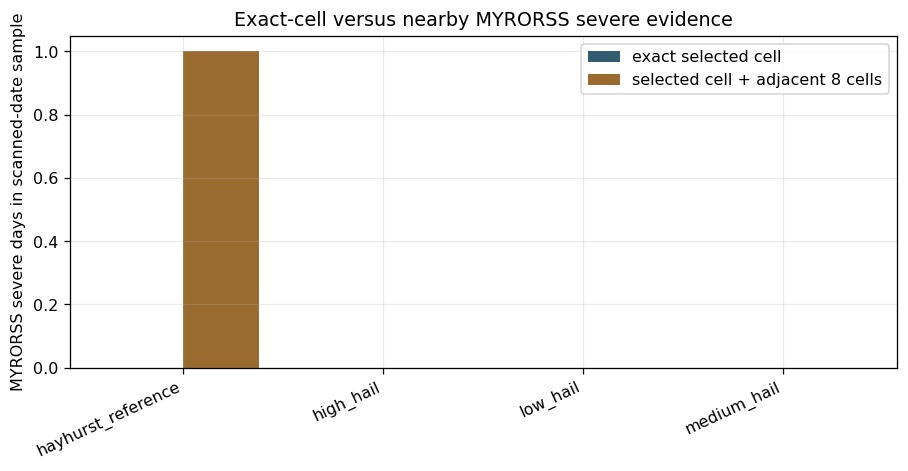

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.2))
plot_summary = summary.sort_values("role")
x = np.arange(len(plot_summary))
width = 0.38
ax.bar(x - width / 2, plot_summary["n_myrorss_hail_days"], width, color="#315c72", label="exact selected cell")
ax.bar(
    x + width / 2,
    plot_summary["n_dates_with_neighbor_3x3_severe_mesh"],
    width,
    color="#9a6b2f",
    label="selected cell + adjacent 8 cells",
)
ax.set_xticks(x)
ax.set_xticklabels(plot_summary["role"], rotation=25, ha="right")
ax.set_ylabel("MYRORSS severe days in scanned-date sample")
ax.set_title("Exact-cell versus nearby MYRORSS severe evidence")
ax.tick_params(axis="x", rotation=25)
ax.legend()
plt.tight_layout()
plt.show()

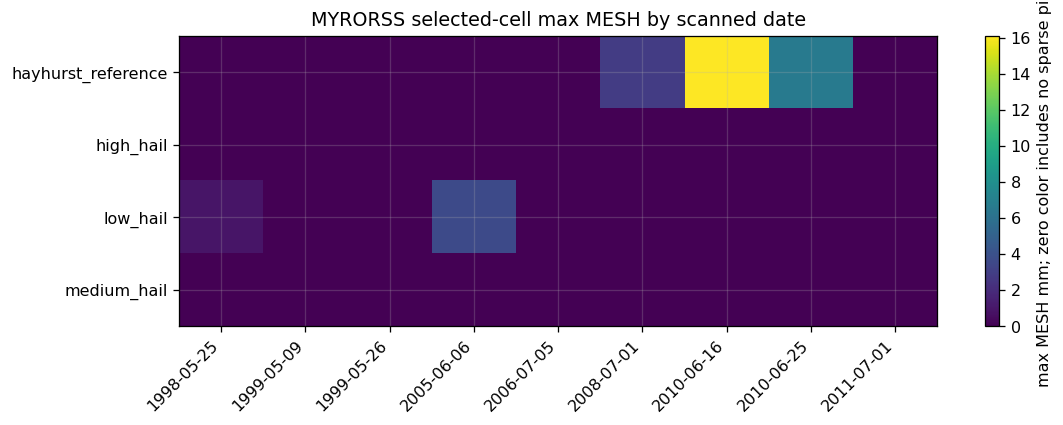

In [10]:
heat = panel.pivot(index="role", columns="date", values="mesh_max_mm")
fig, ax = plt.subplots(figsize=(10, 3.8))
im = ax.imshow(heat.fillna(0), aspect="auto", cmap="viridis")
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=45, ha="right")
ax.set_title("MYRORSS selected-cell max MESH by scanned date")
fig.colorbar(im, ax=ax, label="max MESH mm; zero color includes no sparse pixel")
plt.tight_layout()
plt.show()

**Takeaway.** The summary is useful for source QA: it tells us which selected cells have MYRORSS evidence
on report-guided days and how often report-guided dates fail to land inside the exact 0.25 degree cell.
It is not useful as a rate estimate.

## 8 - Compare with current MRMS selected-cell pilot

This comparison is only to keep our mental model straight. The MRMS pilot is a dense Apr-Jun 2024 bounded
panel. This MYRORSS panel is a report-guided subset of 1998-2011 dates. Different denominator, different
source era, different use.

In [11]:
mrms_panel = pd.read_csv(MRMS_M1_DAILY_PANEL_CSV)
mrms_summary = (
    mrms_panel.groupby(["role", "cell_id"], as_index=False)
    .agg(
        mrms_window_days=("date", "nunique"),
        mrms_hail_days=("hail_day_flag", "sum"),
        mrms_max_mesh_mm=("mesh_max_mm", "max"),
        mrms_total_native_pixels_severe=("n_native_pixels_severe", "sum"),
    )
)
mrms_summary["mrms_pilot_hail_day_fraction"] = (
    mrms_summary["mrms_hail_days"] / mrms_summary["mrms_window_days"]
)

comparison = summary.merge(mrms_summary, on=["role", "cell_id"], how="left")
comparison["comparison_note"] = (
    "MYRORSS denominator is report-guided scanned dates; MRMS denominator is Apr-Jun 2024 pilot days. "
    "Compare behavior only, not rates."
)
display(
    comparison[
        [
            "role",
            "cell_id",
            "n_scanned_dates",
            "n_myrorss_hail_days",
            "max_mesh_mm",
            "n_dates_with_neighbor_3x3_severe_mesh",
            "neighbor_3x3_max_mesh_mm",
            "mrms_window_days",
            "mrms_hail_days",
            "mrms_max_mesh_mm",
            "comparison_note",
        ]
    ]
)

,role,cell_id,n_scanned_dates,n_myrorss_hail_days,max_mesh_mm,n_dates_with_neighbor_3x3_severe_mesh,neighbor_3x3_max_mesh_mm,mrms_window_days,mrms_hail_days,mrms_max_mesh_mm,comparison_note
0,hayhurst_reference,336544,9,0,16.107588,1,37.829437,91,2,33.3,MYRORSS denominator is report-guided scanned d...
1,high_hail,329354,9,0,NaN,0,NaN,91,12,105.8,MYRORSS denominator is report-guided scanned d...
2,low_hail,247197,9,0,3.635974,0,4.335073,91,0,NaN,MYRORSS denominator is report-guided scanned d...
3,medium_hail,261700,9,0,NaN,0,NaN,91,2,37.3,MYRORSS denominator is report-guided scanned d...


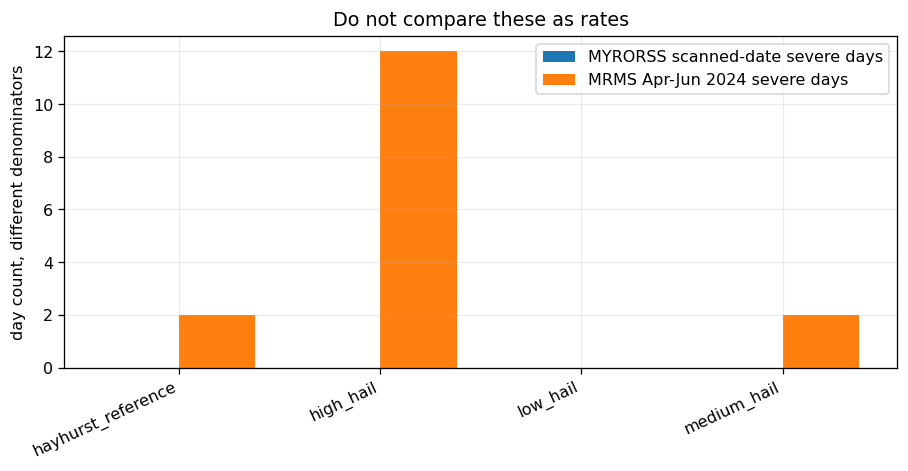

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(comparison))
width = 0.38
ax.bar(x - width / 2, comparison["n_myrorss_hail_days"], width, label="MYRORSS scanned-date severe days")
ax.bar(x + width / 2, comparison["mrms_hail_days"], width, label="MRMS Apr-Jun 2024 severe days")
ax.set_xticks(x)
ax.set_xticklabels(comparison["role"], rotation=25, ha="right")
ax.set_ylabel("day count, different denominators")
ax.set_title("Do not compare these as rates")
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway.** This is a source-behavior comparison only. If the MYRORSS selected-cell scan finds fewer
exact-cell hits than reports suggest, that may be spatial mismatch, MESH threshold behavior, source-era
differences, or report bias. It is not yet calibration.

## 9 - Write artifacts

The outputs are intentionally named `report_guided`. That word is a safety label: this is a stress-test
sample, not a climatology.

In [13]:
scan_dates.to_csv(SCAN_DATES_CSV, index=False)
panel.to_csv(DAILY_PANEL_CSV, index=False)
summary.to_csv(SUMMARY_CSV, index=False)

metadata = {
    "version": OUTPUT_VERSION,
    "hazard": "hail",
    "source": "MYRORSS",
    "source_product": "MESH/00.25",
    "stage": "M0 selected-cell report-guided scan v0",
    "selected_cells_path": str(SELECTED_CELLS_CSV.relative_to(ROOT)),
    "date_selection": {
        "method": "top cached NOAA 25-mile report dates per selected-cell role plus source-probe day",
        "dates_per_role": DATES_PER_ROLE,
        "source_probe_date": SOURCE_PROBE_DATE.isoformat(),
        "n_unique_scan_dates": int(scan_date_context["date"].nunique()),
        "n_panel_rows": int(len(panel)),
        "n_selected_cells": int(len(selected_ids)),
        "n_scan_target_cells_including_3x3_neighbors": int(len(scan_target_ids)),
    },
    "scan_coverage": {
        "n_source_files_total": int(sum(day["n_source_files"] for day in day_meta)),
        "n_empty_source_files_total": int(sum(day["n_empty_source_files"] for day in day_meta)),
        "n_read_failures_total": int(sum(day["n_read_failures"] for day in day_meta)),
        "scan_dates": day_meta,
    },
    "outputs": {
        "scan_dates_csv": str(SCAN_DATES_CSV.relative_to(ROOT)),
        "daily_panel_csv": str(DAILY_PANEL_CSV.relative_to(ROOT)),
        "summary_csv": str(SUMMARY_CSV.relative_to(ROOT)),
    },
    "allowed_use": [
        "selected-cell MYRORSS scanner validation",
        "source behavior review against report-guided dates",
        "exact-cell versus 3x3-neighborhood spatial mismatch diagnostics",
        "input for designing full selected-cell MYRORSS record scan",
    ],
    "not_allowed_use": [
        "annual frequency estimate",
        "final MYRORSS climatology",
        "MRMS replacement",
        "reportable EAL/PML/VaR/TVaR input",
    ],
    "caveats": [
        "dates are selected using NOAA reports and are not an unbiased sample",
        "NOAA reports are not treated as grid truth",
        "3x3-neighborhood diagnostics are QA context only, not the selected-cell event definition",
        "MYRORSS sparse-grid pixels do not provide the same denominator as dense MRMS daily tiles",
        "cross-era/source consistency with MRMS remains unresolved",
        "MESH bias and tail treatment remain unresolved",
    ],
}
METADATA_JSON.write_text(json.dumps(metadata, indent=2) + "\n")

print("wrote:", SCAN_DATES_CSV.relative_to(ROOT))
print("wrote:", DAILY_PANEL_CSV.relative_to(ROOT))
print("wrote:", SUMMARY_CSV.relative_to(ROOT))
print("wrote:", METADATA_JSON.relative_to(ROOT))

wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_scan_dates_v2026_06_16.csv
wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_report_guided_daily_panel_v2026_06_16.csv
wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_report_guided_summary_v2026_06_16.csv
wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_report_guided_metadata_v2026_06_16.json


## 10 - Next step

This scan proves the selected-cell scanner and surfaces the right caveats. Before widening, document the
source-promotion gate:

```text
coverage denominator
  -> exact target vs neighborhood QA
  -> source-era comparability with MRMS
  -> MESH bias/de-bias status
  -> frequency/event definition
  -> tail-treatment status
```

Only after that should we run wider selected-cell batches or consider full CONUS.